# Figure 5: Phase-dependent effects of beta and gamma rhythmic inhibition on dendritic spikes

**Paper:** Headley DB, Latimer B, Aberbach A, Nair SS (2026). Spatially targeted inhibitory rhythms differentially affect neuronal integration. *eLife*. https://doi.org/10.7554/eLife.95562

## Overview

This notebook analyzes how rhythmic inhibition at beta (16 Hz) and gamma (64 Hz) frequencies modulates dendritic spikes and action potentials in a layer 5 pyramidal neuron model. As described in the paper, distal dendritic inhibition modulates the occurrence of dendritic spikes, while perisomatic inhibition alters action potential generation. This translates into location-specific differences in the effectiveness of inhibitory rhythms.

## Simulation Conditions

Two key simulations are analyzed (matching Figure 5 from the paper):

1. **16 Hz Beta rhythmic inhibition** (20% depth of modulation) delivered to **distal dendrites** (>100 µm from soma)
2. **64 Hz Gamma rhythmic inhibition** (40% depth of modulation) delivered **perisomatically** (soma and dendrites <100 µm)

For both conditions, excitatory synaptic drive was a stable Poisson process. The different depths of modulation ensured that these rhythms produced similar entrainment of action potentials.

## Key Findings (Figure 5)

Beta rhythmic inhibition to distal dendrites entrained dendritic spikes, focusing them into the phase when inhibition was at a minimum. The phase of beta modulated the occurrence of Ca²⁺, NMDA, and Na⁺ spikes, with each showing an ~75% depth of modulation with respect to their mean level. These changes were seen across the entire dendritic tree, spanning sites electrotonically close to and far from the soma. In addition, the impact on Na⁺ spikes was unexpected since delivery of the same inhibition tonically had little effect.

By contrast, gamma rhythmic inhibition delivered perisomatically had virtually no effect on dendritic spikes. Its strongest impact was on Na⁺ spikes in basal dendritic compartments that were electrotonically close to the soma. Gamma instead modulated the threshold for action potential initiation through direct shunting at the soma.

Accompanying these effects were changes in the rate of dendritic spikes compared with the Poisson inhibition case. Beta increased the rate of Na⁺ (+16.6%) and Ca²⁺ spikes (+15.1%) but decreased the rate of NMDA spikes (-10.7%). Gamma caused no change in NMDA (+0.2%) and a weak increase in Na⁺ spikes (+6.4%), but a robust gain in Ca²⁺ spikes (+37.9%).

In [37]:
import sys
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import h5py
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.bin_rhythmic_files import bin_rhythmic_files
from src.load_spike_h5 import load_spike_h5
from src.ser_pt import ser_pt
from src.bin_serser import bin_serser
from src.cc_phdep_files import cc_phdep_files

from src.load_dendevt_csv import load_dendevt_csv
from src.seg_dendevt import seg_dendevt
from src.ser_seg_dendevt import ser_seg_dendevt
from src.mean_dendevt import mean_dendevt

## 1.0 Analysis Parameters

Define parameters for phase-binned analysis of dendritic spikes and action potentials during rhythmic inhibition. Events are binned by the phase of the inhibitory rhythm using 8 phase bins from -π to π radians, where -π represents the trough (minimum inhibition) and 0 represents the peak (maximum inhibition).

### 1.1 Simulation Constants and Analysis Windows

Set sampling rate (10 samples/ms), simulation window (200 seconds), spike-triggered average window (±100 ms), and phase binning parameters (8 bins spanning -π to π radians).

In [38]:
samps_per_ms = 10 
sim_win = [0, 2000000] # beginning and start points of simulation in samples
sta_win = [-100, 100] # multiply by step to get window in milliseconds
sta_step = 1 # binning step for each point in the STA
step = 2 * samps_per_ms # number of simulation steps for creating the dendritic 
                        # event occurrence series
ph_bin_num = 8
edges = np.linspace(-np.pi, np.pi, ph_bin_num)

### 1.2 Simulation Files

Define paths to simulation output files for two rhythmic inhibition conditions:

1. **16 Hz beta rhythmic inhibition** (20% depth) delivered to distal dendrites (>100 µm from soma)
2. **64 Hz gamma rhythmic inhibition** (40% depth) delivered perisomatically (soma and dendrites <100 µm)

Beta rhythms were emulated by modulating distal inhibitory synapses at 16 Hz. Gamma rhythms were emulated by modulating perisomatic synapses at 64 Hz. The different depths of modulation ensured that these rhythms produced similar entrainment of action potentials. Excitatory synaptic inputs were stable Poisson processes in both conditions.

In [39]:
# locate simulation files
root_16_dir = 'D:\DendCompOscPublic\\output_16Hz_no_exc_mod\\'
sim_16_dict = {'SimName': 'output_16Hz_no_exc_mod',
               'RootDir': root_16_dir,
               'CaFile': root_16_dir + 'output_16Hz_no_exc_mod_ca.csv',
               'NaFile': root_16_dir + 'output_16Hz_no_exc_mod_na.csv',
               'NMDAFile': root_16_dir + 'output_16Hz_no_exc_mod_nmda.csv',
               'APFile': root_16_dir + 'spikes.h5',
               'InhProxFile': root_16_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_16_dir + 'dist_inh_stim_spikes.h5'}

root_64_dir = 'D:\\DendCompOscPublic\\output_64Hz_no_exc_mod_dom_40p\\'
sim_64_dict = {'SimName': 'output_64Hz_no_exc_mod',
               'RootDir': root_64_dir,
               'CaFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_ca.csv',
               'NaFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_na.csv',
               'NMDAFile': root_64_dir + 'output_64Hz_no_exc_mod_dom_40p_nmda.csv',
               'APFile': root_64_dir + 'spikes.h5',
               'InhProxFile': root_64_dir + 'prox_inh_stim_spikes.h5',
               'InhDistFile': root_64_dir + 'dist_inh_stim_spikes.h5'}


## 2.0 Phase-Binned Histograms for Dendritic and Somatic Spikes

Calculate entrainment of dendritic spikes to inhibitory rhythms by binning dendritic spike times by phase. As described in the methods, dendritic spikes are first converted to a binary time series with 2 ms bins that is true during periods where a dendritic spike was present. The inhibitory rhythm is then binned by phase, with bin widths of π/4, yielding 8 phase bins. The mean of the dendritic spike binary series is taken for each phase bin, converted to percent change from mean, and stratified by electrotonic distance from the soma.

### 2.1 Generate Phase Series for Each Experiment

Generate sinusoidal time series at 16 Hz (beta) and 64 Hz (gamma) frequencies to represent the rhythmic modulation of inhibitory drive. The phase is extracted using the Hilbert transform, allowing each event (dendritic spike or action potential) to be assigned to a phase bin.

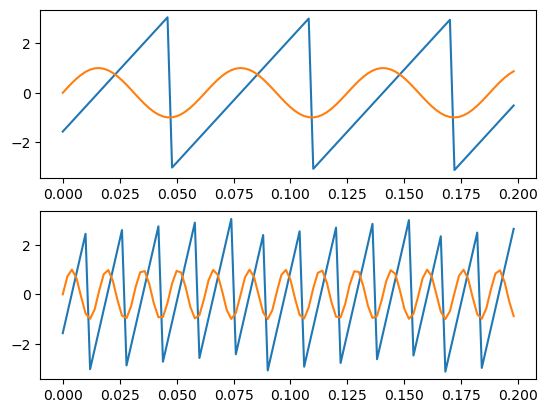

In [40]:
# generate phase time series for inhibitory afferents
t_ser = np.arange(sim_win[0], sim_win[1], step) / (10000) # seconds
sin_16_ser = np.sin(t_ser*16*2*np.pi)
sin_64_ser = np.sin(t_ser*64*2*np.pi)
ph_16_ser = np.angle(hilbert(sin_16_ser))
ph_64_ser = np.angle(hilbert(sin_64_ser))

fig, ax = plt.subplots(2,1)
ax[0].plot(t_ser[0:100],ph_16_ser[0:100])
ax[0].plot(t_ser[0:100],sin_16_ser[0:100])
ax[1].plot(t_ser[0:100],ph_64_ser[0:100])
ax[1].plot(t_ser[0:100],sin_64_ser[0:100])
plt.show()

### 2.2 Calculate Phase-Binned Histograms

Process each simulation to compute phase-dependent modulation of dendritic spikes (Ca²⁺, NMDA, Na⁺) and action potentials. Dendritic spikes are stratified by electrotonic distance from the soma and binned by the phase of the inhibitory rhythm. Results are expressed as percent change from the mean incidence across the entire simulation.

In [41]:
# phase bin dendritic and action potential files function
def bin_files_func(sim_dict, ph_ser, sin_ser):
    ph_bin = {}

    # process dendritic events
    ph_bin['ca_bin'] = bin_rhythmic_files(sim_dict['CaFile'], ph_ser, step, sim_win,ph_bin_num)
    ph_bin['nmda_bin'] = bin_rhythmic_files(sim_dict['NMDAFile'], ph_ser, step, sim_win,ph_bin_num)
    ph_bin['na_bin'] = bin_rhythmic_files(sim_dict['NaFile'], ph_ser, step, sim_win,ph_bin_num)

    ph_bin['ca_a'] = ph_bin['ca_bin'].loc['apic','ph_bin']
    ph_bin['nmda_a'] = ph_bin['nmda_bin'].loc['apic','ph_bin']
    ph_bin['nmda_b'] = ph_bin['nmda_bin'].loc['dend','ph_bin']
    ph_bin['na_a'] = ph_bin['na_bin'].loc['apic','ph_bin']
    ph_bin['na_b'] = ph_bin['na_bin'].loc['dend','ph_bin']
    

    # process action potential events
    spk_t = load_spike_h5(sim_dict['APFile'])
    spk_ser = ser_pt(spk_t, step, sim_win)
    spk_ser = np.array(spk_ser)*500
    # multiplying by 500 converts to firing rates, 2ms bin means 1 spike per bin
    # is a firing rate of 500 Hz.
    ph_bin['ap'] = bin_serser(spk_ser.astype(float), ph_ser, edges, func=np.nanmean)["values"]
    ph_bin['sin'] = bin_serser(sin_ser, ph_ser, edges, func=np.nanmean)["values"]
    return ph_bin



In [42]:
# process the 16 Hz distal dendritic inhibition simulation
ph_16_bin = bin_files_func(sim_16_dict, ph_16_ser, sin_16_ser)

# process the 64 Hz proximal dendritic/somatic inhibition simulation
ph_64_bin = bin_files_func(sim_64_dict, ph_64_ser, sin_64_ser)

c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\load_dendevt_csv.py:32: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  dspk_df = pd.read_csv(fpath)
c:\Users\dbh60\Documents\Analysis\InhibOnDendComp\scripts\..\src\bin_serser.py:60: RuntimeWarning: Mean of empty slice
  bin_temp.append(func(val_ser[bin_inds == curr_ind]))
c:\Users\dbh60\.conda\envs\dend_comp\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\Users\dbh60\Documents\Analys

### 2.3 Visualization

Plot phase histograms showing how event incidence varies with inhibitory rhythm phase. Plots span 2 full cycles (-π to 3π) for clarity, with the black line showing the sinusoidal modulation of inhibitory drive. These visualizations correspond to Figure 5 panels B-E (16 Hz beta) and G-J (64 Hz gamma) from the paper, showing action potential firing rate and dendritic spike modulation by rhythm phase.

In [43]:
# plotting functions
def stairs_plot(sig_ser, sin_ser, ax):
        sc_func = lambda x: ((x+1)/2)*np.max(sig_ser[1:])

        ax.stairs(np.hstack((sig_ser[1:],sig_ser[1:])),
                np.hstack((edges[:-1], edges+2*np.pi)), 
                baseline=0, fill=True)
        ax.plot(np.hstack((edges, edges+2*np.pi)), 
                np.hstack((sc_func(sin_ser), sc_func(sin_ser))),color='k')
        ax.plot(np.linspace(-np.pi,3*np.pi,100),
                sc_func(np.sin(np.linspace(-np.pi,3*np.pi,100)+(np.pi/2))), 
                color='r', linestyle=':')
        ax.set_xticks(np.pi/2*np.arange(-2,7))
        ax.tick_params(axis='x', rotation=90)

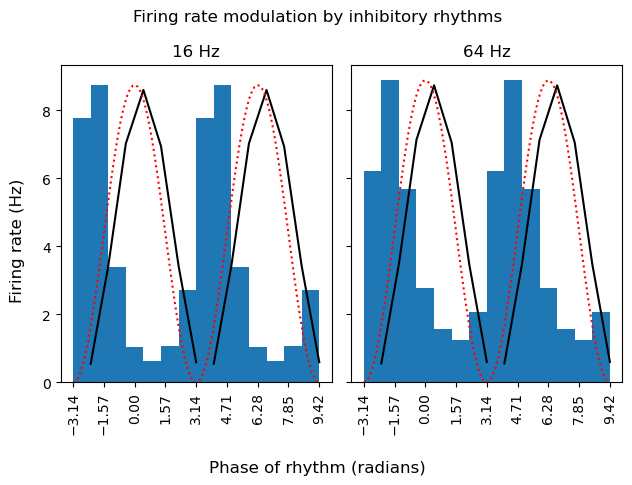

In [44]:
# Action potentials
fig, ax = plt.subplots(1,2,sharey=True)
stairs_plot(ph_16_bin['ap'], ph_16_bin['sin'], ax[0])
stairs_plot(ph_64_bin['ap'], ph_64_bin['sin'], ax[1])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Firing rate modulation by inhibitory rhythms')
fig.supxlabel('Phase of rhythm (radians)')
fig.supylabel('Firing rate (Hz)')
plt.tight_layout()


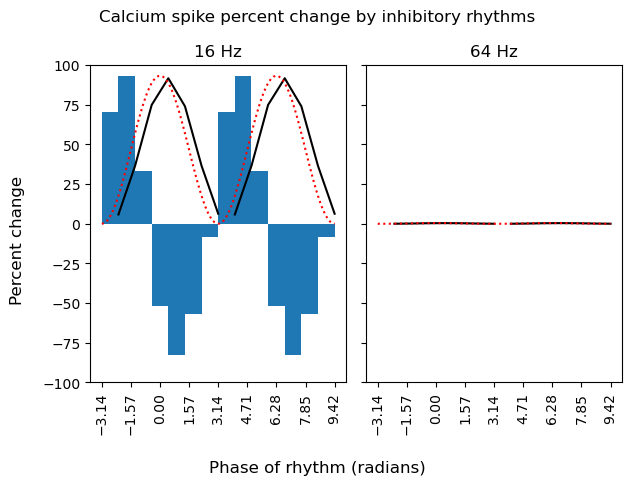

In [45]:
# calcium spikes
fig, ax = plt.subplots(1,2,sharey=True)
stairs_plot(ph_16_bin['ca_a'][0], ph_16_bin['sin'], ax[0])
stairs_plot(ph_64_bin['ca_a'][0], ph_64_bin['sin'], ax[1])
ax[0].set_ylim([-100,100])
ax[0].set_title('16 Hz')
ax[1].set_title('64 Hz')
fig.suptitle('Calcium spike percent change by inhibitory rhythms')
fig.supxlabel('Phase of rhythm (radians)')
fig.supylabel('Percent change')
plt.tight_layout()

### 2.4 Dendritic Event Modulation Heatmaps

Visualize dendritic spike modulation as heatmaps stratified by electrotonic distance (y-axis, where 9 = most distal) and rhythm phase (x-axis, in radians). Beta rhythmic inhibition produces strong ~75% modulation across the entire dendritic tree for Ca²⁺, NMDA, and Na⁺ spikes. By contrast, gamma rhythmic inhibition has minimal effect on dendritic spikes except for Na⁺ spikes in basal dendrites electrotonically close to the soma. These patterns reflect the matching of rhythm timescales to dendritic spike durations: beta cycles (~62 ms at 16 Hz) align with the slow NMDA (~20-80 ms) and Ca²⁺ spikes (~20-50 ms), while gamma cycles (~15 ms at 64 Hz) are too fast to effectively modulate these slow events.

In [46]:
# plot phase-dependent modulation of dendritic events stratified by electrotonic distance
eqt_list = np.arange(9,0,-1)
eqt_inds = np.where(eqt_list>0)[0]
def plot_sta_im(data_arr,vlim, ax):
    ax_im = ax.imshow(np.hstack((data_arr[eqt_inds[0]:eqt_inds[-1],1:], 
                                 data_arr[eqt_inds[0]:eqt_inds[-1],1:])),
                      extent=[-np.pi, 3*np.pi, eqt_list[eqt_inds[0]], eqt_list[eqt_inds[-1]]],
                      vmin=vlim[0], vmax=vlim[1],
                      interpolation='none',
                      cmap='coolwarm')
    
    plt.colorbar(ax_im,ax=ax)
    ax.set_aspect('auto')

# array plots
def plot_dend_set(ph_bin_data, vlim, fig, ax):
    plot_sta_im(ph_bin_data['nmda_a'], vlim, ax[0,0])
    ax[0,0].set_title('NMDA Apical')
    ax[0,0].set_xticks(np.pi/2*np.arange(-2,7))
    ax[0,0].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['nmda_b'], vlim, ax[1,0])
    ax[1,0].set_title('NMDA Basal')
    ax[1,0].set_xticks(np.pi/2*np.arange(-2,7))
    ax[1,0].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['na_a'], vlim, ax[0,1])
    ax[0,1].set_title('Na Apical')
    ax[0,1].set_xticks(np.pi/2*np.arange(-2,7))
    ax[0,1].tick_params(axis='x', rotation=90)
    plot_sta_im(ph_bin_data['na_b'], vlim, ax[1,1])
    ax[1,1].set_title('Na Basal')
    ax[1,1].set_xticks(np.pi/2*np.arange(-2,7))
    ax[1,1].tick_params(axis='x', rotation=90)
    fig.supxlabel('Phase of rhythm (radians)')
    fig.supylabel('Electrotonic quantile 90->0')
    

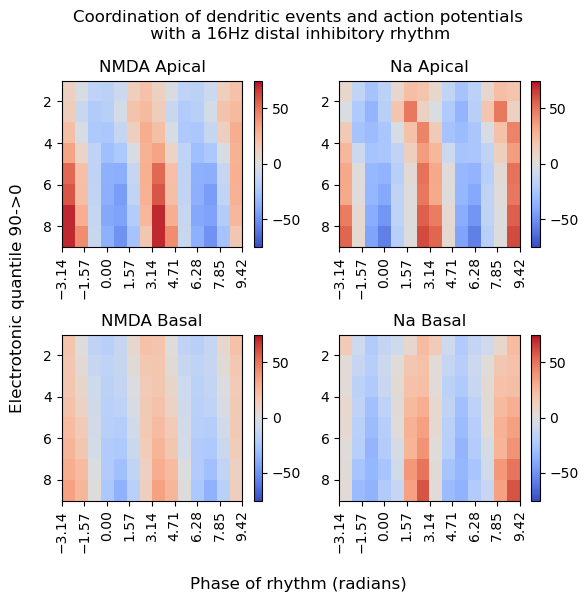

In [47]:
# plot of NMDA and Na spikes for 16 hz dend inhib
fig,ax = plt.subplots(2,2)
plot_dend_set(ph_16_bin, [-75, 75], fig, ax)
fig.suptitle('Coordination of dendritic events and action potentials\n'
             + ' with a 16Hz distal inhibitory rhythm')
fig.set_size_inches(6,6)
fig.tight_layout()


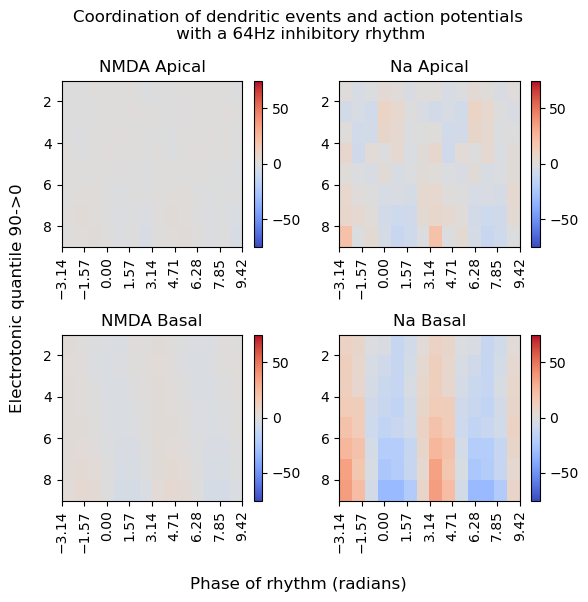

In [48]:
# plot of NMDA and Na spikes for 64 hz somatic inhib
fig,ax = plt.subplots(2,2)
plot_dend_set(ph_64_bin, [-75, 75], fig, ax)
fig.suptitle('Coordination of dendritic events and action potentials\n'
             + ' with a 64Hz inhibitory rhythm')
fig.set_size_inches(6,6)
fig.tight_layout()